In [120]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


In [25]:
alfac = 1/np.sqrt(2)
gammas = np.arange(1.2, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gammas - 1) * np.log(alfac**2) ) )

print(gammas, alfas)

[1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] [0.93303299 0.90125046 0.87055056 0.84089642 0.8122524  0.7845841
 0.75785828 0.73204285 0.70710678]


No handles with labels found to put in legend.


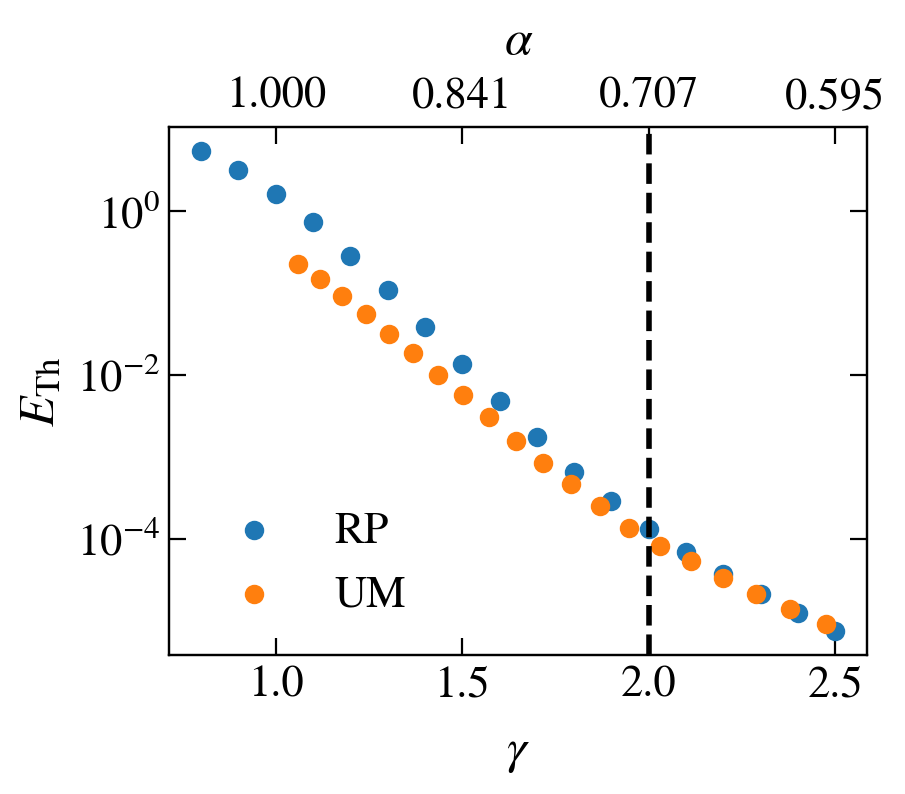

In [111]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(6, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(0.8, 2.6, 0.1)

ymin = 1e6
axis2 = axis.twiny()

# ------------------------------------------------------------ ROZENZWEIG-PORTER
E_th = np.zeros(gammas.shape)
for iig, gx in enumerate(gammas):
    name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            sigma = np.mean( np.array(file.get('bandwidth')) )
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            
            omegax = np.array(file.get('omegas'))
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx]
            spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
            yy0 = spec_fun * 2**L
            
            omegax = omegax[~np.isnan(yy0)]
            spec_fun = spec_fun[~np.isnan(yy0)]
            spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            
            # xx = omegax#[indices]
            # yy = yy0#[indices]
            # pars, pconv= fit(lorenz,
            #             xdata = omegax,
            #             ydata = yy0,
            #             maxfev = 20000)
            # G = np.abs(pars[-1])
            xx = omegax
            yy = integrate.cumulative_trapezoid(yy0, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            G = xx[1:][idxG]
            
            E_th[iig] = G
    else:
        print(name)
axis.scatter(gammas, E_th, label=r"RP" )
    
# ------------------------------------------------------------ ULTRAMETRIC MODEL
bandwidth_ = np.transpose(np.array([[14.15529694,14.18783681,13.79809073,14.70243885,14.15699668,14.09174666,13.97159135,14.54182027,14.56108004,14.94075512,14.72489892,14.26014434,15.08897824,15.21879211,15.08696013,14.82103569,15.16009597,15.44983645,15.46168321,16.42984215]]))
name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        alfas = np.array(file.get('Sz/0/alphas/mean'))
        indices = np.argwhere( np.logical_and(alfas >= 0.591, alfas < 1) )
        alfas = alfas[indices]
        _gammas_ = 1 + np.log(alfas**2) / np.log(alfac**2)
        
        E_th2 = []
        for iia, alfa in enumerate(alfas):
            omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(alfa) ))# / bandwidth_[iia]
            spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(alfa) ))
            
            xx = omegas
            yy = integrate.cumulative_trapezoid(spec_fun, omegas)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            E_th2.append( omegas[1:][idxG] )
            
        # E_th2 = np.array(file.get('Sz/0/gamma/mean'))[indices]# / dim**(1 - _gammas_)
        axis.scatter(_gammas_, E_th2, label=r"UM")
        
else:
    print(name_out)
        
# axis.plot(gammas, dim**(1-gammas) )

axis.axvline(x=2, ls='--', color='k', lw=2)
fig_help.set_plot_elements(axis, ylabel=r"$E_{\rm Th}$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)


fig.subplots_adjust(wspace = 0.2, hspace=0.2)

No handles with labels found to put in legend.


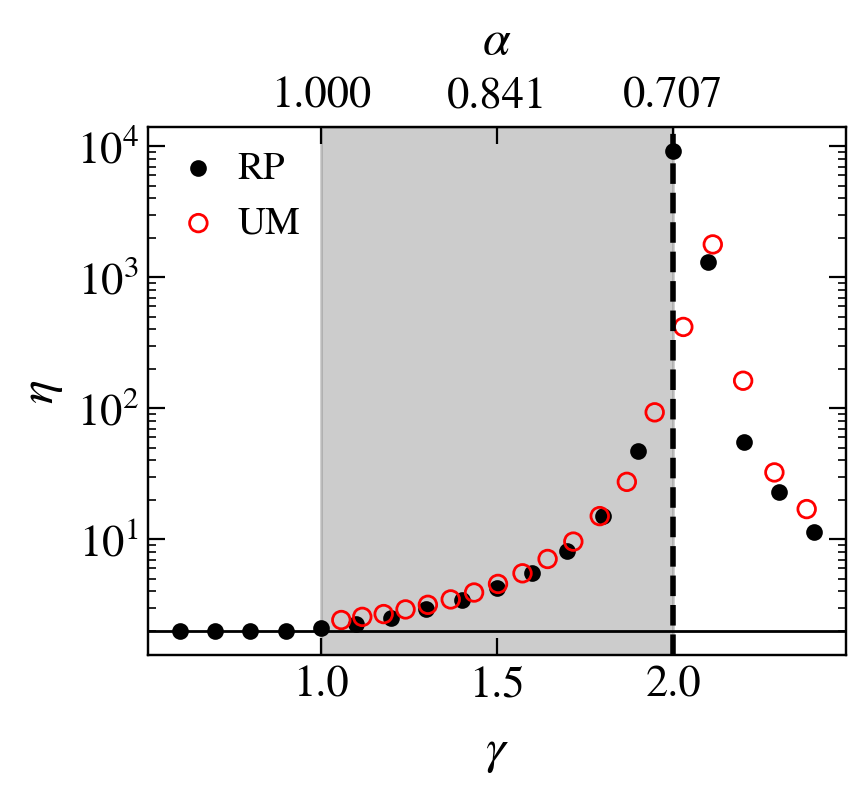

In [184]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(6, 17, 1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.5), dpi = 200, sharex=False, sharey=False)

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 100

L = 15
eps = 0.5
alfac = 1/np.sqrt(2)

dim = 2**L

gammas = np.arange(0.6, 2.5, 0.1)

ymin = 1e6
axis2 = axis.twiny()

# ------------------------------------------------------------ ROZENZWEIG-PORTER
def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-eta)

etaRP = np.zeros(gammas.shape)
for iig, gx in enumerate(gammas):
    DOS = np.zeros(sizes.shape)
    spec_at_wH_G = np.zeros(sizes.shape)
    for iiL, L in enumerate( sizes ):
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                sigma = np.mean( np.array(file.get('bandwidth')) )
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
                _DOS = np.array(file.get('DOS'))[idx]
                DOS[iiL] = _DOS
                wHx = np.array(file.get('wH_density'))[idx]
                yy0 = spec_fun
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                
                idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wHx * G)))
                
                spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[ max(0, idx_spec - 20) : min(idx_spec + 20, yy0.size)]) )
        else:
            print(name)
    DOS = DOS[~np.isnan(spec_at_wH_G)]
    sizes = sizes[~np.isnan(spec_at_wH_G)]
    spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]

    pars, pconv= fit(matelem_fit,
                xdata = DOS[-4:],
                ydata = spec_at_wH_G[-4:],
                maxfev = 20000)
    etaRP[iig] = 1 / np.abs(pars[-1])
    # a1 = -1 / ( (np.log(spec_at_wH_G[-1]) - np.log(spec_at_wH_G[-2])) / (np.log(DOS[-1]) - np.log(DOS[-2])) )
    # a2 = -1 / ( (np.log(spec_at_wH_G[-2]) - np.log(spec_at_wH_G[-3])) / (np.log(DOS[-2]) - np.log(DOS[-3])) )
    # etaRP[iig] = (a1 + a2)/2
axis.scatter(gammas, etaRP, label=r"RP", zorder=0, color='k', s=25)
    
# ------------------------------------------------------------ ULTRAMETRIC MODEL
name_out = "./UM results/SpectralFun/etas.h5"
if exists(name_out):
    with h5py.File(name_out, "r") as file:
        alfas = np.array(file.get('Sz/0/etas/mean'))[:, 0]
        _gammas_ = 1 + np.log(alfas**2) / np.log(alfac**2)
        
        etas = np.array(file.get('Sz/0/etas/mean'))[:, 1]
        indices = np.argwhere( np.logical_and(alfas >= 0.617, alfas < 1.1) )
        axis.scatter(_gammas_[indices], etas[indices], label=r"UM", zorder=1, color='red', facecolor='None', s=40)
        
else:
    print(name_out)
        

axis.axvline(x=2, ls='--', color='k', lw=2)
axis.axvspan(xmin=1, xmax=2, color='gray', alpha=0.4, zorder=-1)
axis.axhline(y=2, ls='-', color='k', lw=1)

fig_help.set_plot_elements(axis, ylabel=r"$\eta$", xlabel=r"$\gamma$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, loc='upper left', fontsize=14)

fig_help.set_plot_elements(axis2, ylabel=r"", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='log')
axis.tick_params(axis='both', which='major', direction="in",length=6, labelsize=16, bottom=True, top=False, left=True, right=True)
axis2.tick_params(axis='both', which='major', direction="in", length=6, labelsize=16, bottom=False, top=True, left=True, right=True)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')

ax1Ticks = axis.get_xticks()   
ax2Ticks = ax1Ticks

def tick_function(X):
    V = np.sqrt( np.exp( (X - 1) * np.log(alfac**2) ) )
    return ["%.3f" % z for z in V]

axis2.set_xticks(ax2Ticks)
axis2.set_xbound(axis.get_xbound())
axis2.set_xticklabels(tick_function(ax2Ticks))

# axis.set_ylim(2e-3, 1)


fig.subplots_adjust(wspace = 0.2, hspace=0.2)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


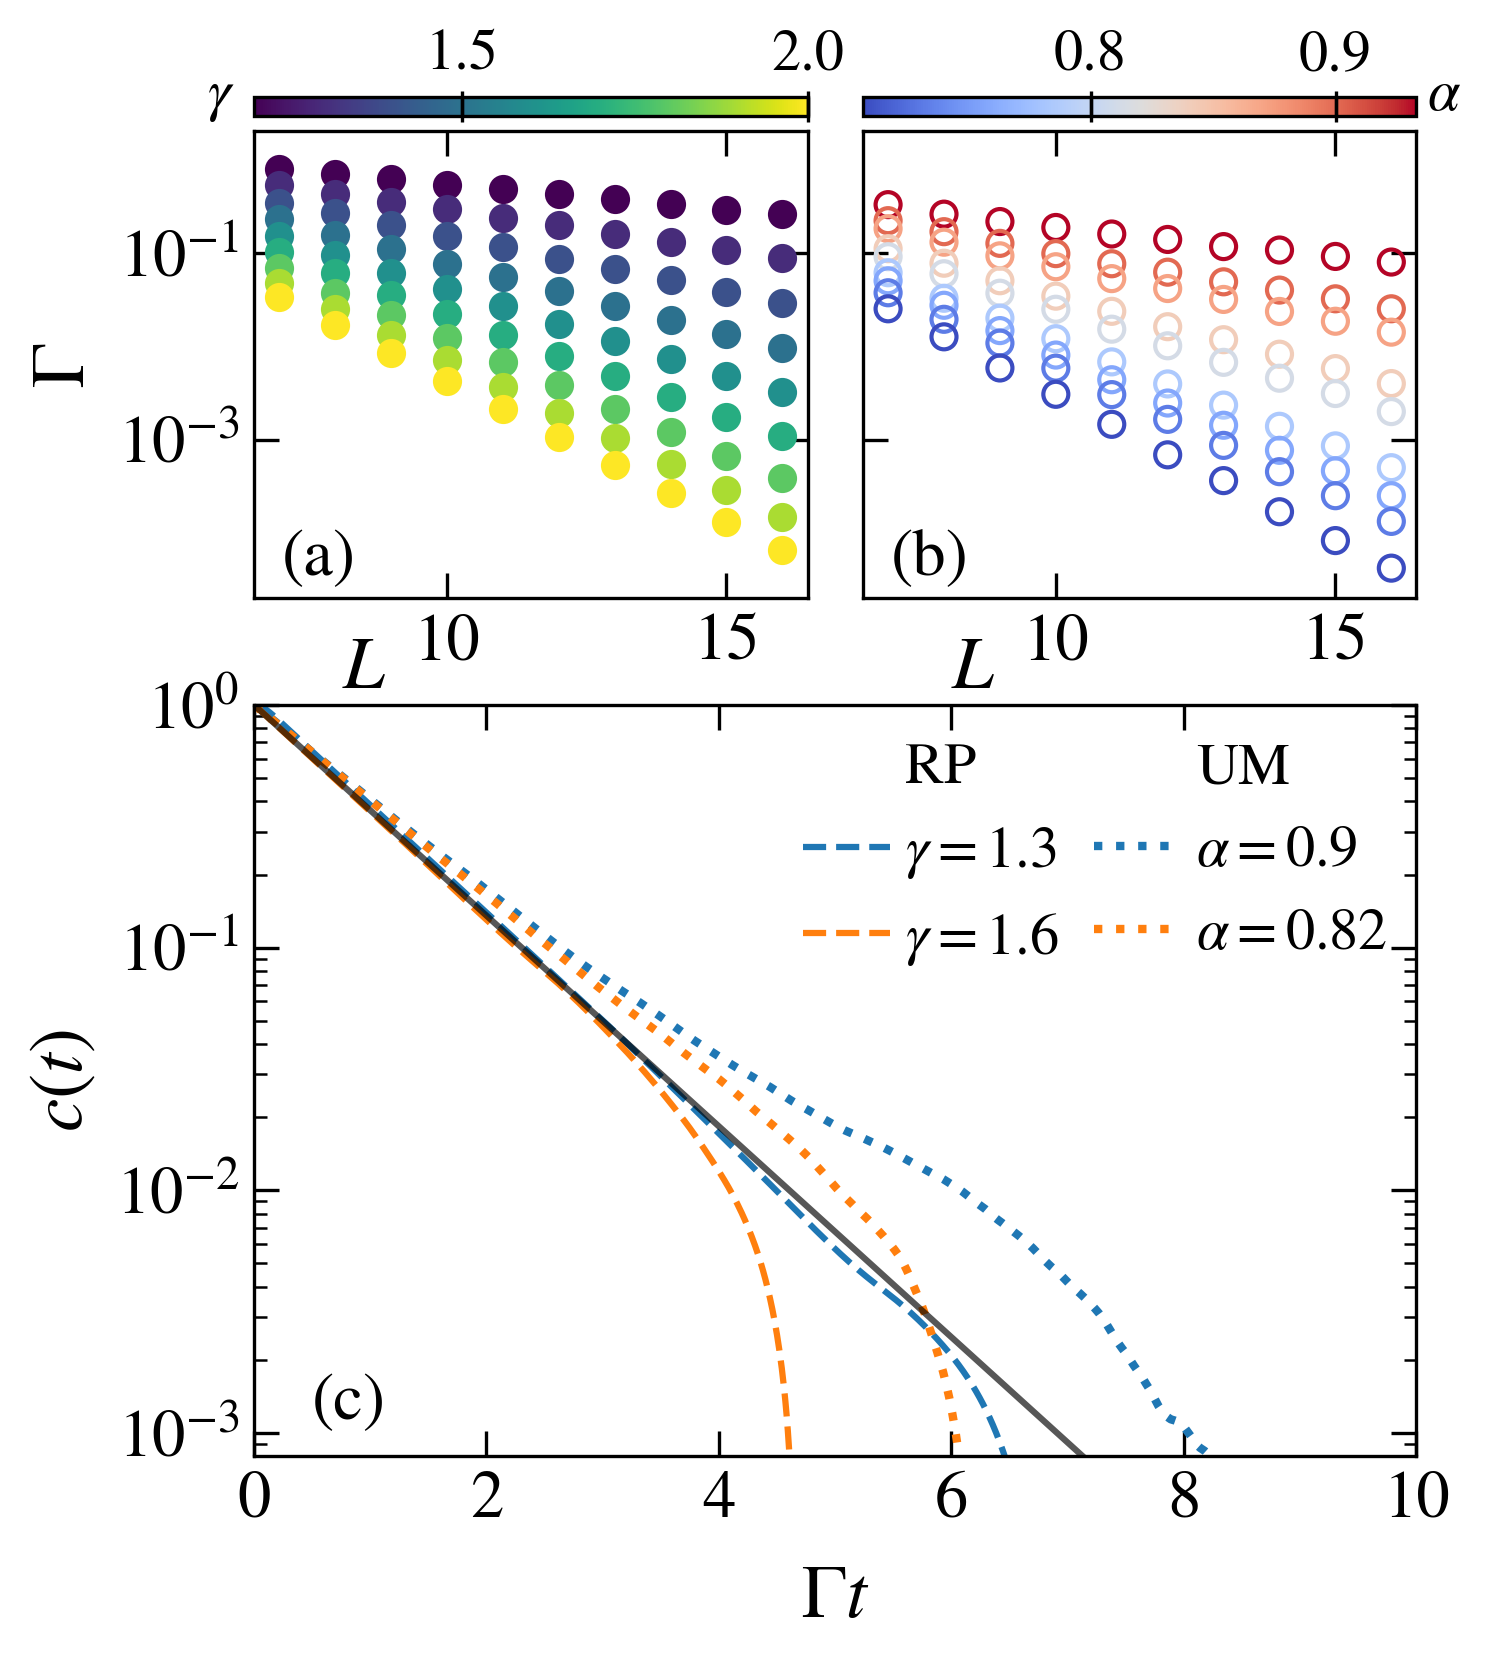

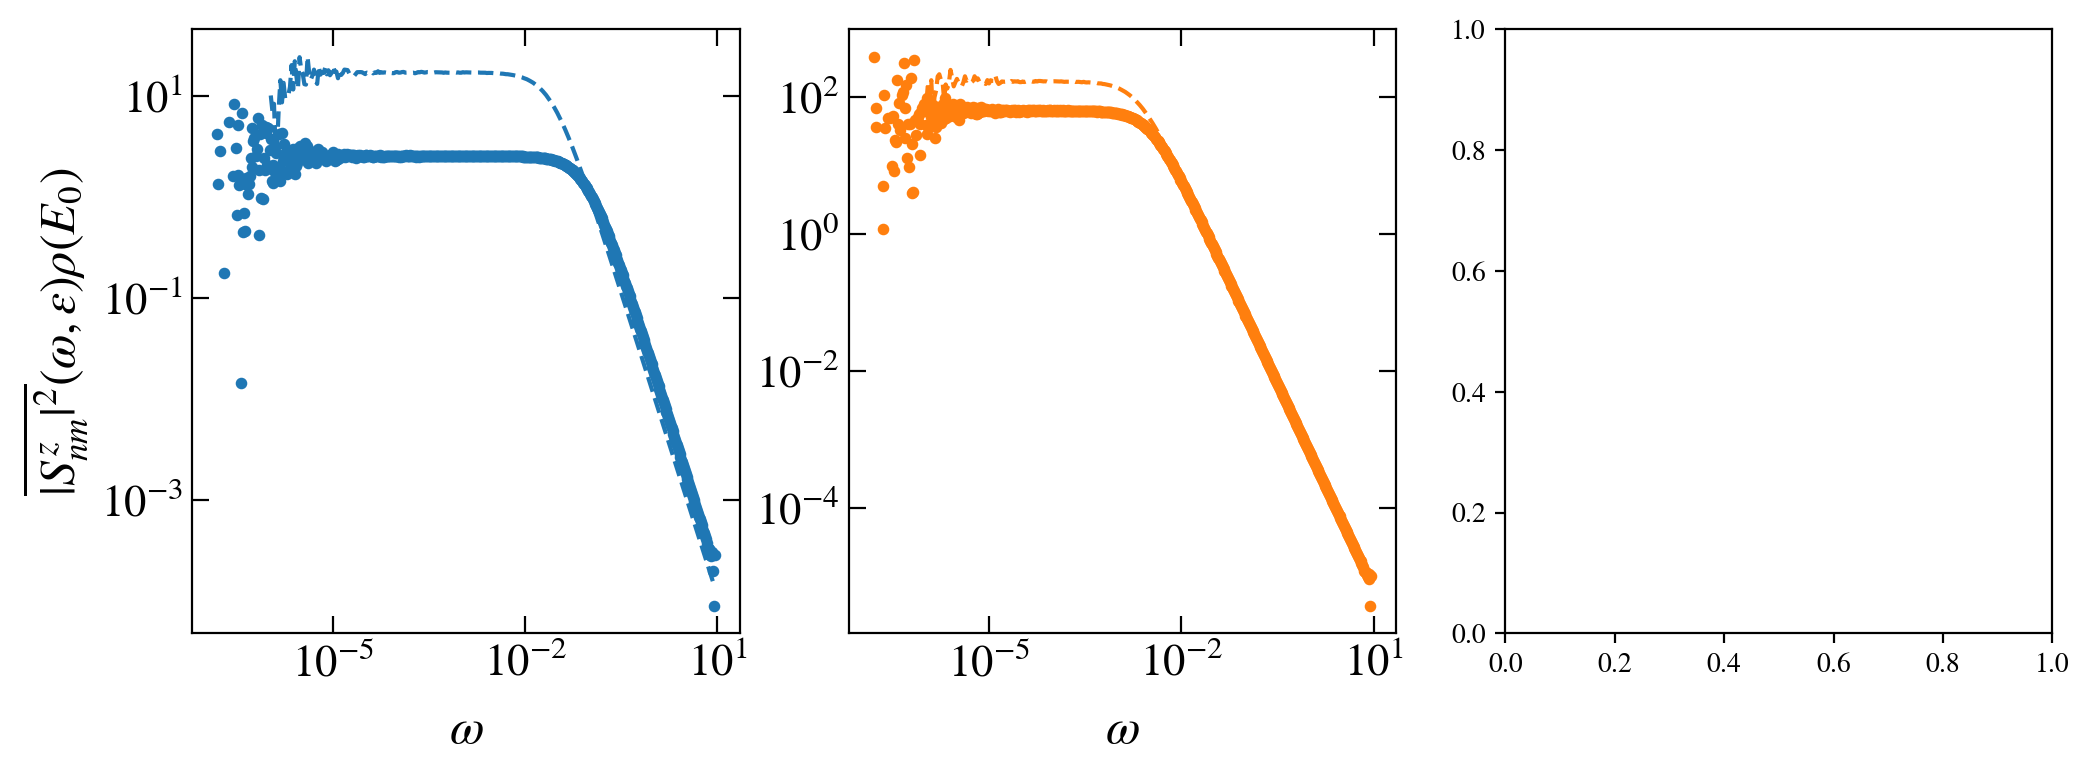

In [183]:
colors_ls_cyc = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'Quench/'

sizes = np.arange(7, 17, 1)

DIM = 1
# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex=False, sharey=False)
fig = plt.figure(figsize=(5,6), dpi = 300)
gs = GridSpec(nrows=2, ncols=2, height_ratios=[2, 3])
axis = fig.add_subplot(gs[1, :])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])


fig2, axis2 = plt.subplots( nrows=1, ncols=3, figsize=(12,4), dpi = 200, sharex=False, sharey=False)

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
gx = 1.5
window = 80

L = 16
eps = 0.5
alfac = 1/np.sqrt(2)

gamma_vals = np.arange(1.2, 2.1, 0.1)
alfas = np.sqrt( np.exp( (gamma_vals - 1) * np.log(alfac**2) ) )
dim = 2**L

def funn(obs, DE):
    return (obs - DE) / (obs[0] - DE)
    # return obs / obs[0]

ymin = 1e6

handles = []

for iig, gx in enumerate([1.3, 1.6]):
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    col = next(colors_ls_cyc)
    
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            wH        = np.array(file.get('wH'))[0]
            tH        = 2 * np.pi / wH
            
            omegax = np.array(file.get('omegas'))# / wH
            omegax = np.sqrt(omegax[1:] * omegax[:-1])
            spec_fun = np.array(file.get('spec_fun'))[idx]
            spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                    
            yy0 = spec_fun * 2**L
            
            omegax = omegax[~np.isnan(yy0)]
            spec_fun = spec_fun[~np.isnan(yy0)]
            spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            axis2[iig].scatter(omegax, yy0, color=col, s=10)
            # xx = omegax#[indices]
            # yy = yy0#[indices]
            # pars, pconv= fit(lorenz,
            #             xdata = omegax,
            #             ydata = yy0,
            #             maxfev = 20000)
            # G = np.abs(pars[-1])
            xx = omegax
            yy = integrate.cumulative_trapezoid(yy0, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            G = xx[1:][idxG]
            
    else:
        print(name)       
    
    name_out = prefix + "Quench_m=%s_J=%g,g=%.2f.hdf5"%(modello, J, gx)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            
            times    = np.array(file.get('TIMES/L=%d'%L))# / tH
            quench = np.array(file.get('QUENCH/L=%d'%L))
            autocorr = np.array(file.get('AUTOCORR/L=%d'%L))
            
            quench = tools.remove_fluctuations(quench, bucket_size=window)[window//2:-window//2]
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            
            DE = np.mean(obs[-1000 : -100])
            
            # DE = np.array(file.get('diagonal ensemble abs'))[L-6]
            
            line, = axis.plot((times * G), funn(obs, DE), color=col, ls = '--', lw=1.5, label = r"$\gamma=%g$"%gx)
            handles.append(line)
            if np.min( np.abs(obs[times < 10/G]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G]) )
    else:
        print(name_out)
    
    
    # ------------------------------------------------------------ ULTRAMETRIC MODEL
    name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            E_th        = np.array(file.get('Sz/0/gamma/mean'))
            wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
            tH        = 2 * np.pi / wH
            # idxa = np.argmin( np.abs(E_th - G) )
            # print(alfa, _alfas_[idxa])
            E_th = E_th[idxa]
            omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]# / wH
            spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
            axis2[iig].plot(omegas, spec_fun, color=col, ls='--')
            # pars, pconv= fit(lorenz,
            #             xdata = omegas,
            #             ydata = spec_fun,
            #             maxfev = 20000)
            # G_UM = np.abs(pars[-1])
            xx = omegas
            yy = integrate.cumulative_trapezoid(spec_fun, omegas)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            idxG = np.argmin( np.abs(yy - 0.5) )
            G_UM = omegas[1:][idxG]
            # print(alfa, _alfas_[idxa], G, G_UM, E_th)
    else:
        print(name_out)
        
    name_out = "./UM results/TimeEvo/Ns=%d.h5"%(L)   
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            _alfas_ = np.array(file.get('Sz/0/ME/alphas'))
            idxa = np.argmin( np.abs(_alfas_ - alfa) )
            
            times = np.array(file.get('Sz/0/ME/autocorr/%d/times'%(idxa) ))# / tH
            autocorr = np.array(file.get('Sz/0/ME/autocorr/%d/mean'%(idxa) )) / 4
            
            autocorr = tools.remove_fluctuations(autocorr, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            # print(autocorr)
            
            obs = autocorr
            
            DE = np.mean(obs[-1000 : -100])
            # DE = np.array(file.get('Sz/0/ME/stat/lt/ac/typical' ))[idxa]
            line, = axis.plot((times * G_UM), funn(obs, DE), color=col, ls=':', lw=2, label = r"$\alpha=%g$"%(_alfas_[idxa]))
            handles.append(line)
            
            if np.min( np.abs(obs[times < 10/G_UM]) ) < ymin: ymin = np.min( np.abs(obs[times<10/G_UM]) )
    else:
        print(name_out)
    
    fig_help.set_plot_elements(axis2[iig], ylabel=r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)\rho(E_0)$" if iig==0 else "", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

line, = axis.plot(np.nan, np.nan, color='k', ls=':', lw=0,label = r"UM")
handles.append(line)
line, = axis.plot(np.nan, np.nan, color='k', ls='--', lw=0, label = r"RP")
handles.append(line)
indices = np.array([5,0,2, 4,1,3])

_handle_shit = []
for id in indices:
    _handle_shit.append( handles[id] )
    
fig_help.set_plot_elements(axis, ylabel=r"$c(t)$", xlabel=r"$\Gamma t$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=14, loc='upper right', ncol = 2, handles = _handle_shit, columnspacing=0.6)
axis.set_xlim(0, 10)

times = np.linspace(0, 10, 1000)
axis.plot(times, np.exp(-times), ls='-', color='k', alpha=0.66)
# axis.plot(times, np.exp(-0.9*times), ls='-', color='red', alpha=0.5)
# axis.plot(times, np.exp(-times*np.log(2)/3), ls='--', color='k')
axis.set_ylim(8e-4, 1)
cbar = None

s_m_g = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(gamma_vals), vmax=max(gamma_vals)))
s_m_g.set_array([])

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=min(alfas), vmax=max(alfas)))
s_m_a.set_array([])

for iig, gx in enumerate(gamma_vals):
    alfa = np.sqrt( np.exp( (gx - 1) * np.log(alfac**2) ) )
    
    E_th_RP = np.zeros(sizes.shape)
    E_th_UM = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        # ------------------------------------------------------------ ROZENZWEIG-PORTER
        name = base_dir(model=modello, d=DIM) + 'SpectralFunctions/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                wH        = np.array(file.get('wH'))[0]
                tH        = 2 * np.pi / wH
                
                omegax = np.array(file.get('omegas'))# / wH
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                        
                yy0 = spec_fun * 2**L
                
                omegax = omegax[~np.isnan(yy0)]
                spec_fun = spec_fun[~np.isnan(yy0)]
                spec_fun_typ = spec_fun_typ[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                E_th_RP[iiL] = xx[1:][idxG]
        # ------------------------------------------------------------ ULTRAMETRIC MODEL
        name_out = "./UM results/SpectralFun/Ns=%d.h5"%(L)
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                _alfas_ = np.array(file.get('Sz/0/alphas/mean'))
                idxa = np.argmin( np.abs(_alfas_ - alfa) )
                if np.abs(alfa - _alfas_[idxa]) > 1e-2:
                    print(alfa, name_out)
                    continue
                E_th        = np.array(file.get('Sz/0/gamma/mean'))
                wH        = np.array(file.get('Sz/0/heisenberg/mean'))[idxa]
                tH        = 2 * np.pi / wH
                # idxa = np.argmin( np.abs(E_th - G) )
                # print(alfa, _alfas_[idxa])
                E_th = E_th[idxa]
                omegas      = np.array(file.get('Sz/0/omegas/mean/%.3f'%(_alfas_[idxa]) ))[:-5]# / wH
                spec_fun    = np.array(file.get('Sz/0/f_fun/mean/%.3f'%(_alfas_[idxa]) ))[:-5]
                xx = omegas
                yy = integrate.cumulative_trapezoid(spec_fun, omegas)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                E_th_UM[iiL] = omegas[1:][idxG]
        else:
            print(name_out)
    
    ax1.scatter(sizes, E_th_RP, color=s_m_g.to_rgba(gx))
    ax2.scatter(sizes, E_th_UM, color=s_m_a.to_rgba(alfa), facecolor='None')
    
ax1.xaxis.set_label_coords(0.2, -0.08)
ax2.xaxis.set_label_coords(0.2, -0.08)

fig_help.set_plot_elements(ax1, ylabel=r"$\Gamma$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(ax2, ylabel=r"", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# ax1.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%e"%x))
# ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%e"%x))
ax2.yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))
ax2.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: ""))
ax1.set_ylim(2e-5, 2)
ax2.set_ylim(2e-5, 2)

cbar = None
divider = make_axes_locatable(ax1)
cax = divider.new_vertical(size = '4%', pad = 0.05)
fig.add_axes(cax)
cbar = fig.colorbar(s_m_g, cax = cax, orientation = 'horizontal')
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cax.xaxis.set_label_coords(-0.06, 0.35)
cbar.set_label(r"$\gamma$", fontsize=14)
cax.tick_params(axis='both', which='major', direction="in",length=6, labelsize=14, bottom=True, top=True, left=True, right=True)

cbar = None
divider = make_axes_locatable(ax2)
cax = divider.new_vertical(size = '4%', pad = 0.05)
fig.add_axes(cax)
cbar = fig.colorbar(s_m_a, cax = cax, orientation = 'horizontal')
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cax.xaxis.set_label_coords(1.05, 0.35)
cbar.set_label(r"$\alpha$", fontsize=14)
cax.tick_params(axis='both', which='major', direction="in",length=6, labelsize=14, bottom=True, top=True, left=True, right=True)

ax1.annotate("(a)", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
ax2.annotate("(b)", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
axis.annotate("(c)", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.1, hspace=0.17)

No handles with labels found to put in legend.


../results/RP/Quench/Fourier/realisation=6/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=7/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=8/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=9/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=10/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=11/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=12/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=13/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=14/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=15/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=16/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=17/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=18/_L=9,J=1,g=0.2.hdf5
../results/RP/Quench/Fourier/realisation=19/_L=9,J=1,g=0.2.hdf5


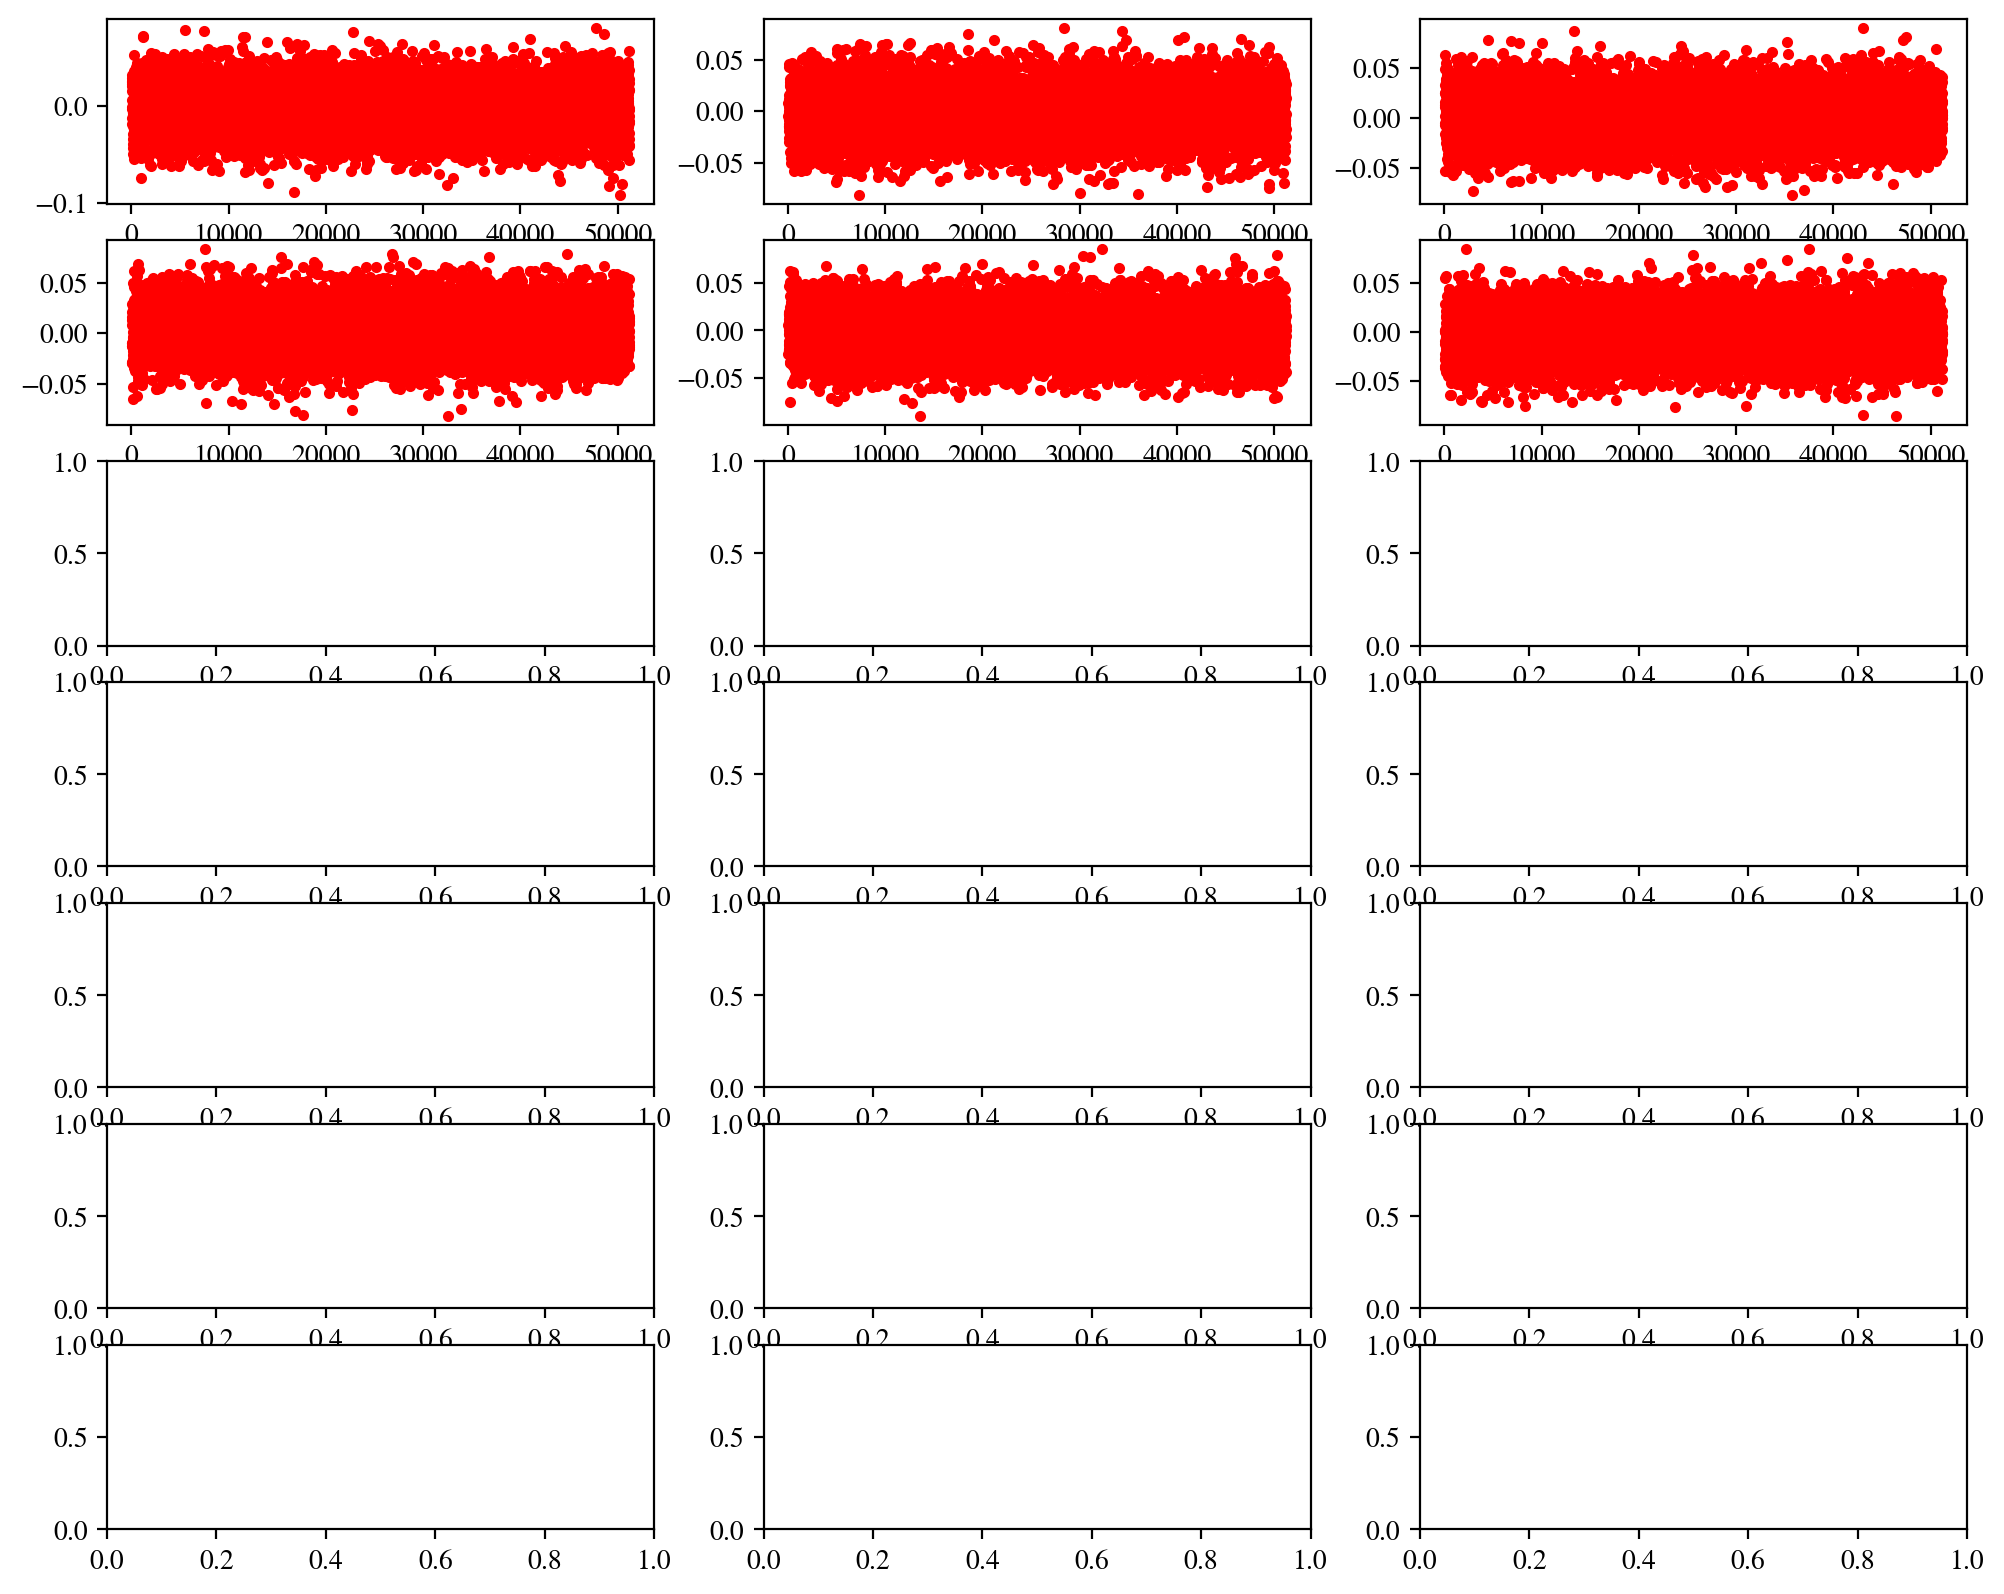

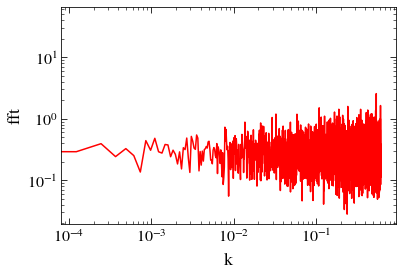

In [373]:
from scipy.fft import fft, fftfreq
from nfft import nfft


L = 9
w = 2
J = 1
g = 0.2
op=0
modello = 'RP'

N = 10000


fig, axs = plt.subplots( nrows=7, ncols=3, figsize=(12,10), dpi = 200)
axs = axs.flatten()
power_spectrum = np.zeros((N//2))
for r in range(20):
    prefix = base_dir(model=modello, d=DIM) + 'Quench/Fourier/realisation=%d/'%r

    name_out = prefix + info(L=L, J=J, g=g, model=modello, ext='.hdf5')
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            times  = np.array(file.get('times'))[0]
            quench = np.array(file.get('quench'))[0]
            T = times[1] - times[0]
            # print(times.size, quench.size)
            power_spectrum += T**2 * np.abs( 2 / np.sqrt(N) * np.abs(fft(quench)[:N//2]) )**2
            axs[r].plot(times, quench, '.', color='red')
    else:
        print(name_out)

xf = 2 * np.pi * fftfreq(N, T)[:N//2]

fig_f, axs_f = plt.subplots(1)
axs_f.plot(xf, power_spectrum, color='red')
fig_help.set_plot_elements(axs_f, ylabel=r"fft", xlabel=r"k", font_size=16, set_legend=1, xscale='log', yscale='log')

plt.show()

In [44]:
pip install nfft

  Created wheel for nfft: filename=nfft-0.1-py3-none-any.whl size=9076 sha256=deea3f4eba8482412d8e0eb4419447bed758f87a05445dfb95e46355608e9996
  Stored in directory: /Users/rafal.swietek/Library/Caches/pip/wheels/19/ff/41/32cb247d0391394dd97dc78b5ab803856f1df814c9c08d51c8
Successfully built nfft
Note: you may need to restart the kernel to use updated packages.


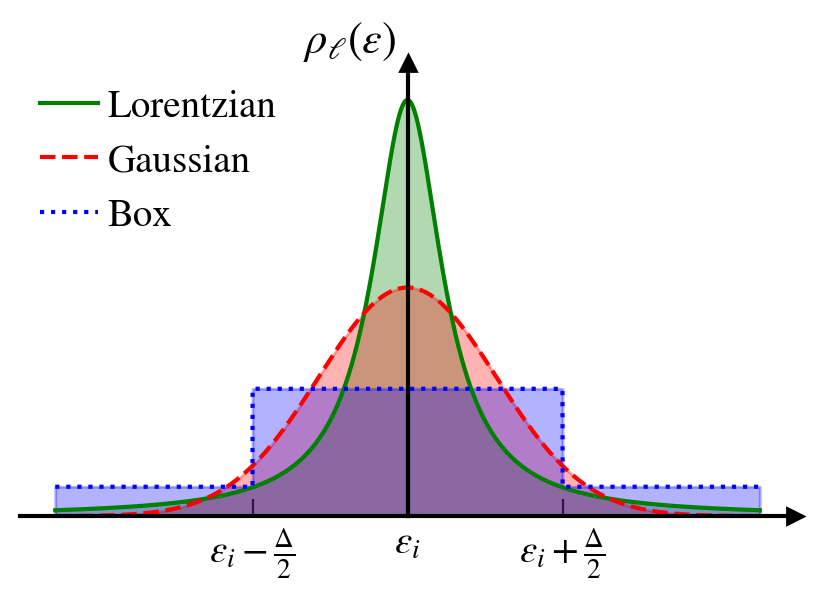

In [315]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

Gamma = 0.03
sigma = 0.002
x0 = 0.0

x = np.linspace(-0.25, 0.25, 10000)
curve1 = 1 / np.pi * Gamma / ((x-x0)**2 + Gamma**2)
curve1 = curve1 / np.trapz(curve1, x)
axis.plot(x, curve1, color='green', label=r"Lorentzian")
axis.fill_between(x, 0, curve1, color='green', alpha=0.3)

x0 = -0.0
curve2 = 1 / np.sqrt(2*np.pi*sigma**2) * np.exp(-(x-x0)**2 / (2*sigma*2))
curve2 = curve2 / np.trapz(curve2, x)
axis.plot(x, curve2, color='red', ls='--', label=r"Gaussian")
axis.fill_between(x, 0, curve2, color='red', alpha=0.3)

Gamma = 0.11
sig2 = 0.3
curve3 = (np.heaviside(Gamma - x,0) + np.heaviside(Gamma + x,0)) - 1 + sig2
curve3 = curve3 / np.trapz(curve3, x)
axis.plot(x, curve3, color='blue', ls=':', label=r"Box")
axis.fill_between(x, 0, curve3, color='blue', alpha=0.3)

fig_help.set_plot_elements(axis, ylabel=r"", xlabel=r"", font_size=14, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(axis, loc='upper left', fontsize=14)
axis.set_ylim(1e-6, 12.5)
axis.set_ylabel(r'$\rho_\ell(\epsilon)$', loc='top', rotation=0)
# axis.set_ylabel(r'$\left|c_\alpha(\epsilon_i)\right|^2$', loc='top', rotation=0)
axis.xaxis.set_label_coords(1, 0.15)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.spines['left'].set_position('zero')
axis.spines['bottom'].set_visible(True)
axis.xaxis.set_ticks_position('bottom')
axis.yaxis.set_ticks_position('left')
axis.set_xticks([-Gamma, 0, Gamma])
axis.set_xticklabels([r"$\epsilon_i-\frac{\Delta}{2}$", r"$\epsilon_i$", r"$\epsilon_i+\frac{\Delta}{2}$"])
axis.set_yticks([])
axis.spines['left'].set_linewidth(1.5)  # Thicker y-axis
axis.spines['bottom'].set_linewidth(1.5)  # Thicker x-axis

# Add arrows at the ends of the axes
axis.plot(1, 0, ">k", transform=axis.get_yaxis_transform(), clip_on=False)  # Arrow for x-axis
axis.plot(0, 1, "^k", transform=axis.get_xaxis_transform(), clip_on=False)  # Arrow for y-axis
